## Chronic Kidney Disease (CKD)

**Chronic Kidney Disease (CKD)** is a long-term medical condition in which the **kidneys gradually lose their ability to filter waste and excess fluids from the blood**. The damage occurs slowly over time and can eventually lead to **kidney failure** if not treated properly.

The kidneys are responsible for several important functions in the body:

- Removing waste products and toxins from the blood  
- Maintaining the balance of fluids and electrolytes  
- Regulating blood pressure  
- Producing hormones that help in red blood cell production and bone health  

When the kidneys are damaged, these functions become impaired, leading to the buildup of waste and fluids in the body.

In [ ]:
# importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [74]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [84]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, roc_auc_score

In [4]:
# suppress all the warnings
warnings.filterwarnings("ignore")

In [5]:
# load the data
df = pd.read_csv(r"../dataset/kidney_disease.csv")
df.head(5)

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


# Chronic Kidney Disease (CKD) Dataset - Column Descriptions

This dataset from the [UCI Machine Learning Repository](https://archive-beta.ics.uci.edu/dataset/336/chronic%2Bkidney%2Bdisease) is used to predict whether a patient has chronic kidney disease (CKD) based on clinical and laboratory features.

---

## Features

| Column | Description | Type / Notes |
|--------|-------------|--------------|
| age | Patient age in years | Numeric |
| bp | Blood pressure (diastolic) in mm/Hg | Numeric |
| sg | Specific gravity of urine | Categorical (e.g., 1.005, 1.010, 1.015, 1.020, 1.025) |
| al | Albumin level in urine | Categorical (scale 0–5) |
| su | Sugar in urine | Categorical (scale 0–5) |
| rbc | Red blood cells in urine | Nominal (*normal*, *abnormal*) |
| pc | Pus cells in urine | Nominal (*normal*, *abnormal*) |
| pcc | Pus cell clumps | Nominal (*present*, *notpresent*) |
| ba | Bacteria in urine | Nominal (*present*, *notpresent*) |
| bgr | Blood glucose random (mg/dl) | Numeric |
| bu | Blood urea (mg/dl) | Numeric |
| sc | Serum creatinine (mg/dl) | Numeric |
| sod | Sodium (mEq/L) | Numeric |
| pot | Potassium (mEq/L) | Numeric |
| hemo | Hemoglobin (gms) | Numeric |
| pcv | Packed cell volume (%) | Numeric |
| wbcc | White blood cell count (cells/cumm) | Numeric |
| rbcc | Red blood cell count (millions/cmm) | Numeric |
| htn | Hypertension | Nominal (*yes*, *no*) |
| dm | Diabetes mellitus | Nominal (*yes*, *no*) |
| cad | Coronary artery disease | Nominal (*yes*, *no*) |
| appet | Appetite | Nominal (*good*, *poor*) |
| pe | Pedal edema | Nominal (*yes*, *no*) |
| ane | Anemia | Nominal (*yes*, *no*) |

---

## Target Variable

| Column | Description |
|--------|-------------|
| class | Chronic kidney disease status: *ckd* → patient has CKD, *notckd* → patient does **not** have CKD |

---

### Notes
- The dataset contains both **numerical** and **categorical** features.  
- Many columns have **missing values**, so preprocessing like **imputation or row/column removal** is necessary before modeling.

In [6]:
df.shape

(400, 26)

In [7]:
df.isnull().sum() / 400 * 100

id                 0.00
age                2.25
bp                 3.00
sg                11.75
al                11.50
su                12.25
rbc               38.00
pc                16.25
pcc                1.00
ba                 1.00
bgr               11.00
bu                 4.75
sc                 4.25
sod               21.75
pot               22.00
hemo              13.00
pcv               17.75
wc                26.50
rc                32.75
htn                0.50
dm                 0.50
cad                0.50
appet              0.25
pe                 0.25
ane                0.25
classification     0.00
dtype: float64

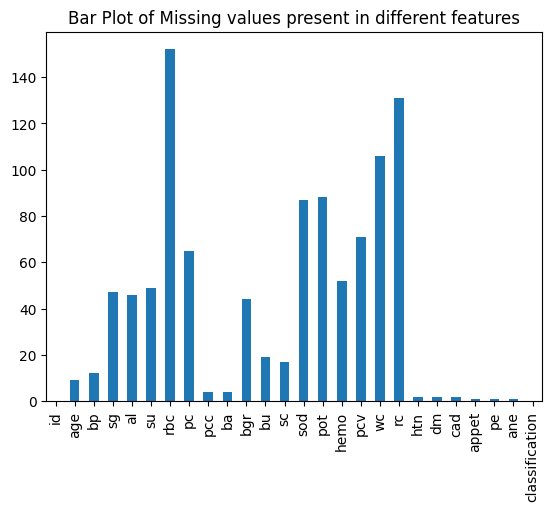

In [8]:
df.isnull().sum().plot(kind="bar", title="Bar Plot of Missing values present in different features")
plt.show()

In [9]:
df.duplicated().sum()

0

## **Data Cleaning**

In [10]:
# removing id column and those columns having missing value percentage >= 20%
df_new = df.drop(columns=['id', 'rbc', 'wc', 'rc', 'sod', 'pot']).copy()
df_new

,age,bp,sg,al,su,pc,pcc,ba,bgr,bu,sc,hemo,pcv,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,normal,notpresent,notpresent,121.0,36.0,1.2,15.4,44.0,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,normal,notpresent,notpresent,NaN,18.0,0.8,11.3,38.0,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,notpresent,notpresent,423.0,53.0,1.8,9.6,31.0,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,abnormal,present,notpresent,117.0,56.0,3.8,11.2,32.0,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,notpresent,notpresent,106.0,26.0,1.4,11.6,35.0,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,normal,notpresent,notpresent,140.0,49.0,0.5,15.7,47.0,no,no,no,good,no,no,notckd
396,42.0,70.0,1.025,0.0,0.0,normal,notpresent,notpresent,75.0,31.0,1.2,16.5,54.0,no,no,no,good,no,no,notckd
397,12.0,80.0,1.020,0.0,0.0,normal,notpresent,notpresent,100.0,26.0,0.6,15.8,49.0,no,no,no,good,no,no,notckd
398,17.0,60.0,1.025,0.0,0.0,normal,notpresent,notpresent,114.0,50.0,1.0,14.2,51.0,no,no,no,good,no,no,notckd


In [11]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             391 non-null    float64
 1   bp              388 non-null    float64
 2   sg              353 non-null    float64
 3   al              354 non-null    float64
 4   su              351 non-null    float64
 5   pc              335 non-null    object 
 6   pcc             396 non-null    object 
 7   ba              396 non-null    object 
 8   bgr             356 non-null    float64
 9   bu              381 non-null    float64
 10  sc              383 non-null    float64
 11  hemo            348 non-null    float64
 12  pcv             329 non-null    float64
 13  htn             398 non-null    object 
 14  dm              398 non-null    object 
 15  cad             398 non-null    object 
 16  appet           399 non-null    object 
 17  pe              399 non-null    obj

In [12]:
# columns like classification, cad and dm contains escape character
df_new['cad'].value_counts()

cad
no      362
yes      34
\tno      2
Name: count, dtype: int64

In [13]:
df_new['dm'].value_counts()

dm
no       259
yes      135
\tyes      2
\tno       2
Name: count, dtype: int64

In [14]:
df_new['classification'].value_counts()

classification
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64

In [15]:
# replace \t with empty string
df_new['dm'] = df_new['dm'].str.replace('\t', '')
df_new['cad'] = df_new['cad'].str.replace('\t', '')
df_new['classification'] = df_new['classification'].str.replace('\t', '')

In [16]:
df_new['cad'].value_counts()

cad
no     364
yes     34
Name: count, dtype: int64

In [17]:
df_new['dm'].value_counts()

dm
no     261
yes    137
Name: count, dtype: int64

In [18]:
df_new['classification'].value_counts()

classification
ckd       250
notckd    150
Name: count, dtype: int64

## **EDA**

### **Univariate Analysis**

In [19]:
def univariate_numerical(col):
    fig, ax = plt.subplots(1, 2, figsize=(8, 5))

    # plot the histogram
    sns.histplot(df_new, x=col, kde=True, ax=ax[0])

    # plot the boxplot
    sns.boxplot(df_new, y=col,ax=ax[1])

    # set the title of the figure
    fig.suptitle(f"Distribution of {col}")

    plt.tight_layout()
    plt.show()

    # display the skewness
    print(f"Skewness of {col} is {df[col].skew()}")

In [20]:
def univariate_categorical(col):
    fig, ax = plt.subplots(1, 2, figsize=(8, 5))

    # display the unique categories
    unique_categories = df_new[col].value_counts()
    print(unique_categories)

    # plot the bar chart
    sns.barplot(x=unique_categories.index, y=unique_categories.values, ax=ax[0])

    # plot the pie chart
    ax[1].pie(unique_categories, autopct="%.2f", labels=unique_categories.index)

    # set the title of the figure
    fig.suptitle(f"Distribution of {col}")

    plt.tight_layout()
    plt.show()

In [21]:
categorical_columns = df_new.drop(columns='classification').select_dtypes('object').columns
numerical_columns = df_new.select_dtypes('float64').columns

print(f"Categorical Columns: {categorical_columns}")
print(f"Numerical Columns: {numerical_columns}")

Categorical Columns: Index(['pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane'], dtype='object')
Numerical Columns: Index(['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'hemo', 'pcv'], dtype='object')


In [22]:
df_new.describe()

,age,bp,sg,al,su,bgr,bu,sc,hemo,pcv
count,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,348.000000,329.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,12.526437,38.884498
std,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,2.912587,8.990105
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,3.100000,9.000000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,10.300000,32.000000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,12.650000,40.000000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,15.000000,45.000000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,17.800000,54.000000


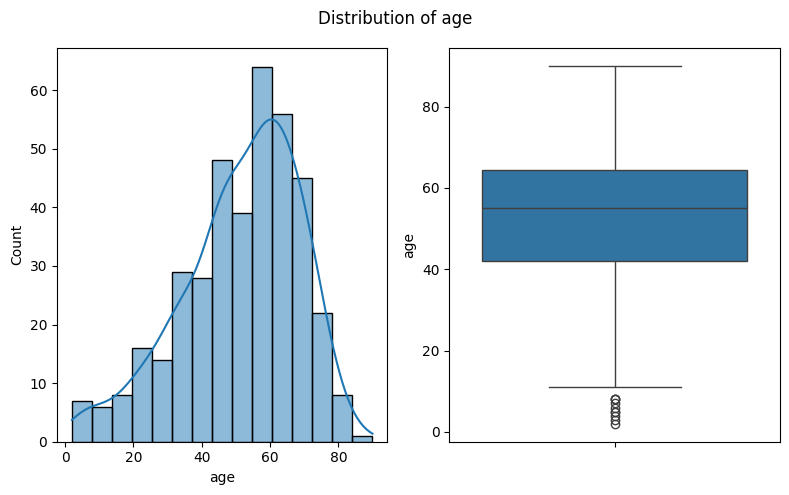

Skewness of age is -0.6682594691593559


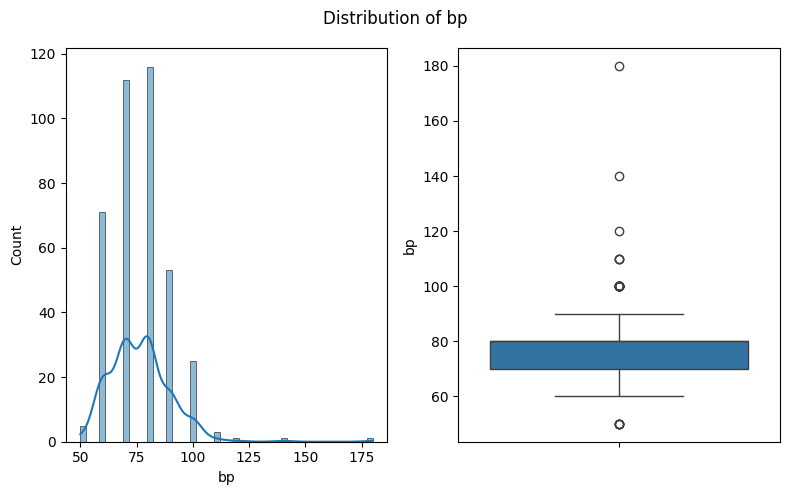

Skewness of bp is 1.6054289569770592


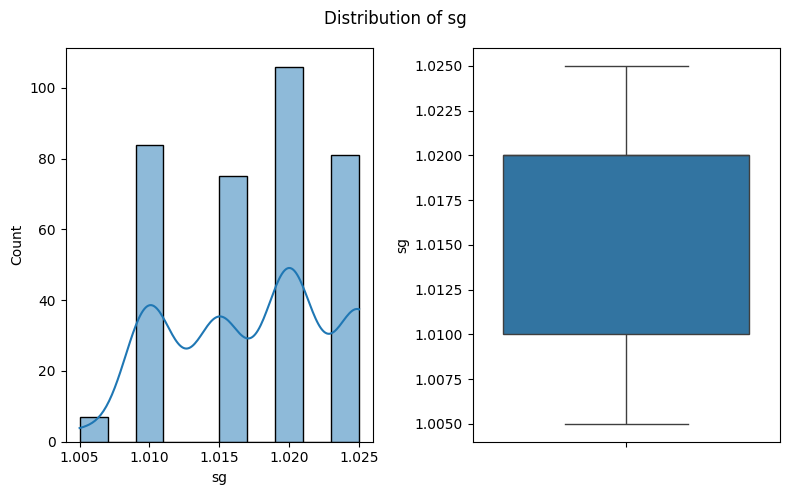

Skewness of sg is -0.1724437507086711


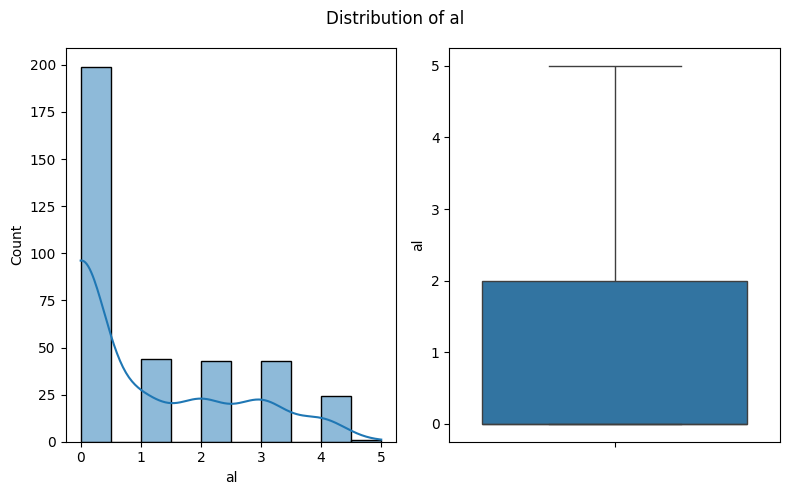

Skewness of al is 0.9981572420526745


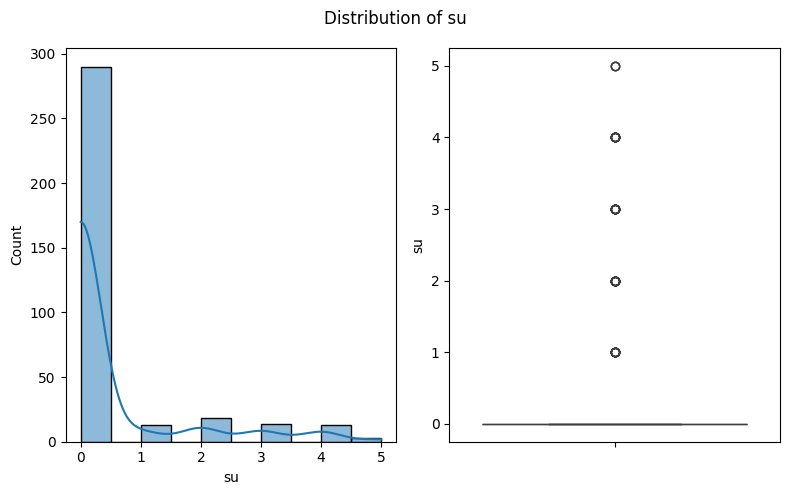

Skewness of su is 2.464261823398267


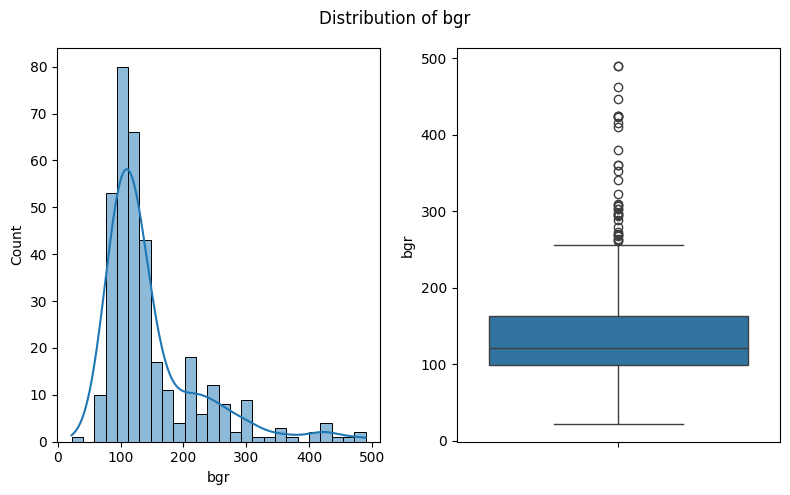

Skewness of bgr is 2.010773172514955


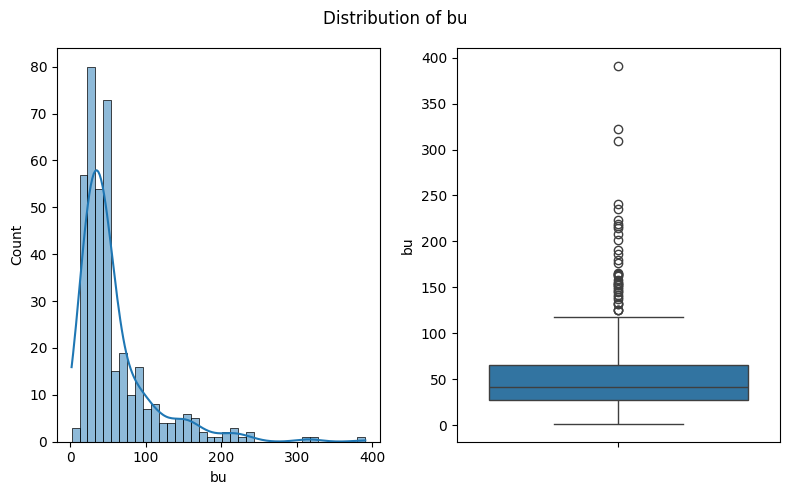

Skewness of bu is 2.6343744585903863


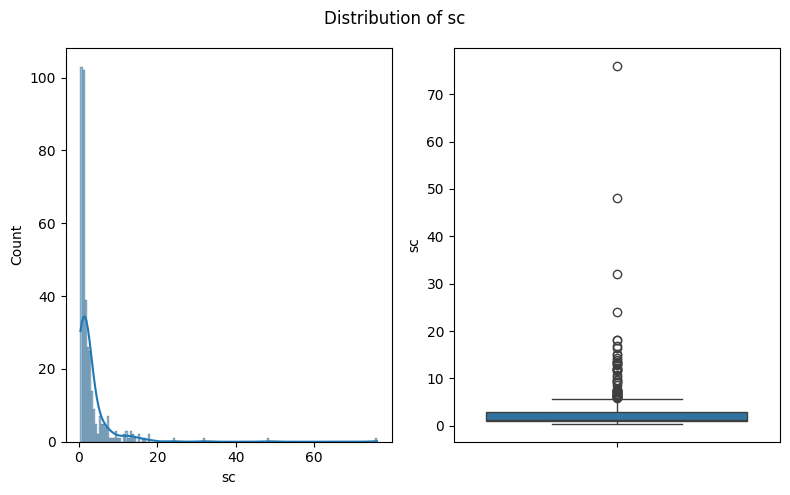

Skewness of sc is 7.509538252140634


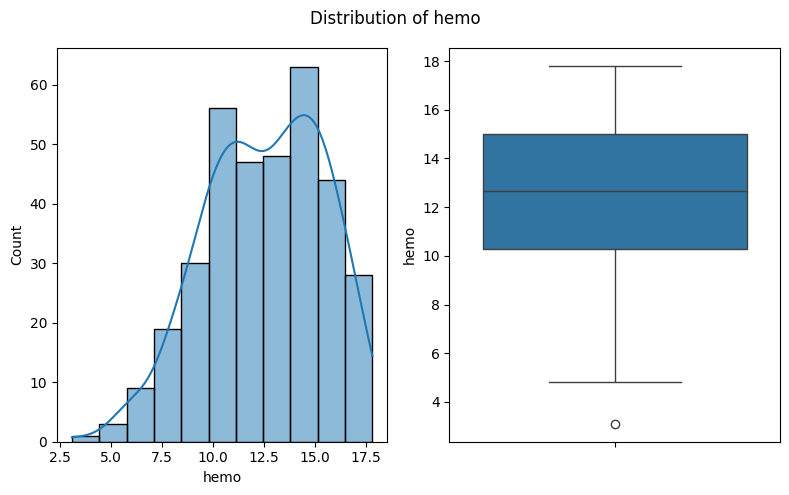

Skewness of hemo is -0.3350946791593011


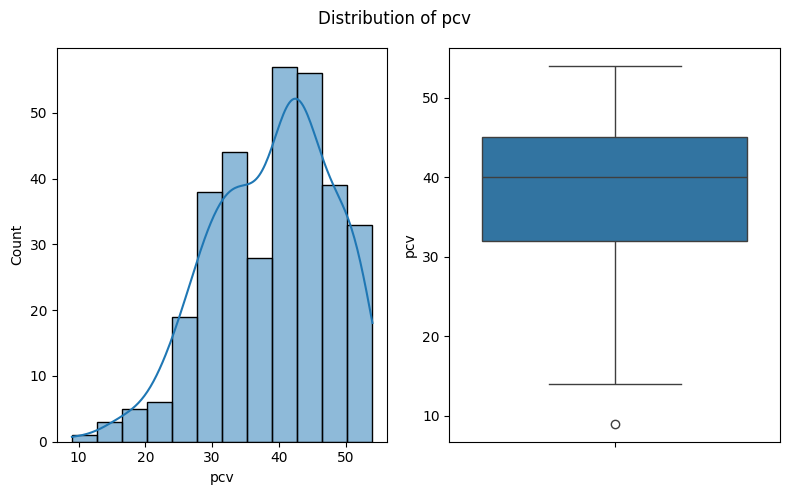

Skewness of pcv is -0.4336785974434392


In [23]:
for numerical_col in numerical_columns:
    univariate_numerical(numerical_col)
    print("="*100)
    print("="*100)

### **Conclusions**
1. **age, pcv, hemo shows little bit of left skewed distribution which can be assumed as normal distribution.** <br>
2. **bgr, bu and sc are highly right skewed with lots of outliers, so try to apply to transformation techniques to make it normal.** <br>
3. **age, bp, pcv, bgr, bu, and sc are showing skewed distribution so we will impute them with median.**

pc
normal      259
abnormal     76
Name: count, dtype: int64


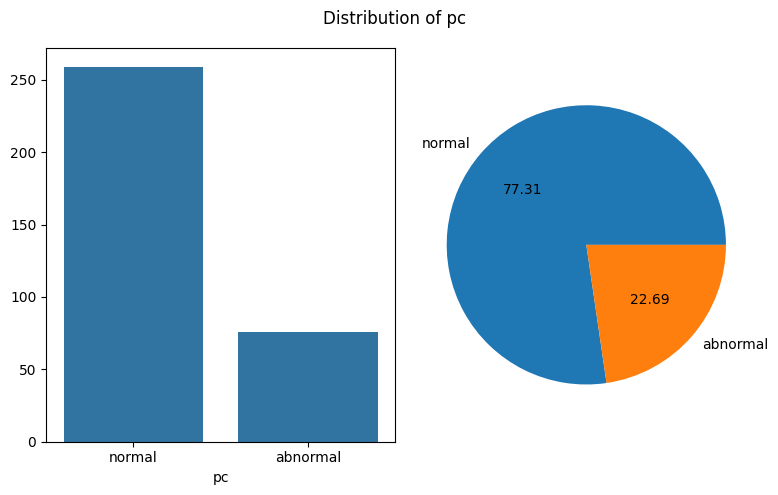

pcc
notpresent    354
present        42
Name: count, dtype: int64


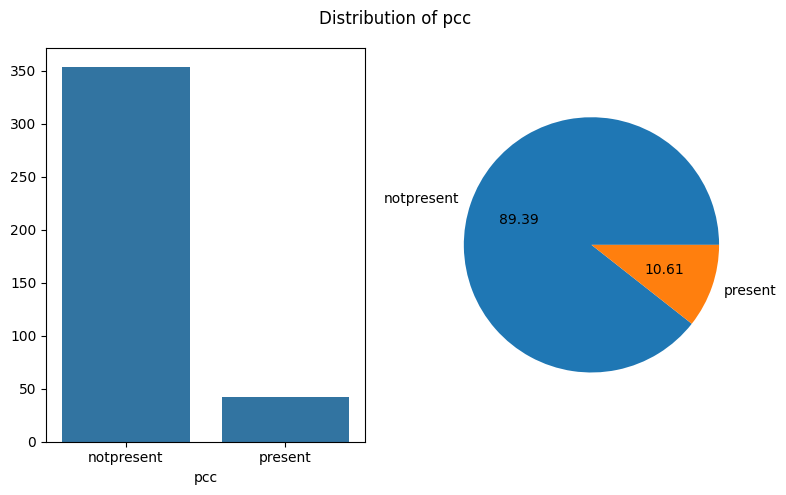

ba
notpresent    374
present        22
Name: count, dtype: int64


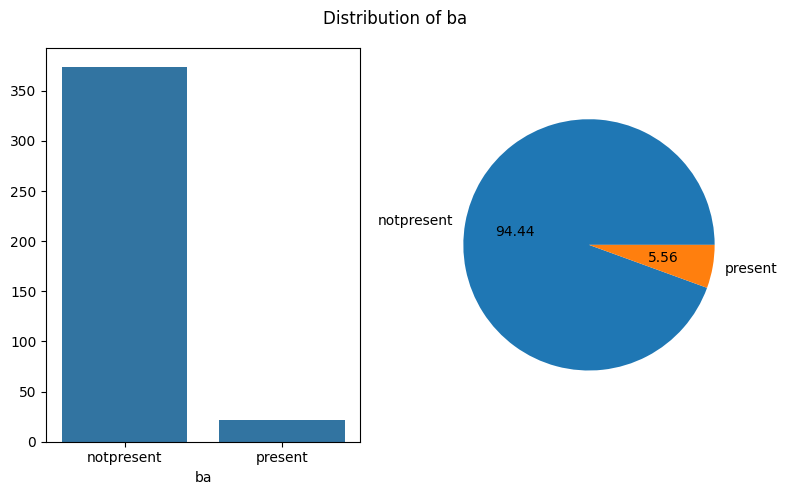

htn
no     251
yes    147
Name: count, dtype: int64


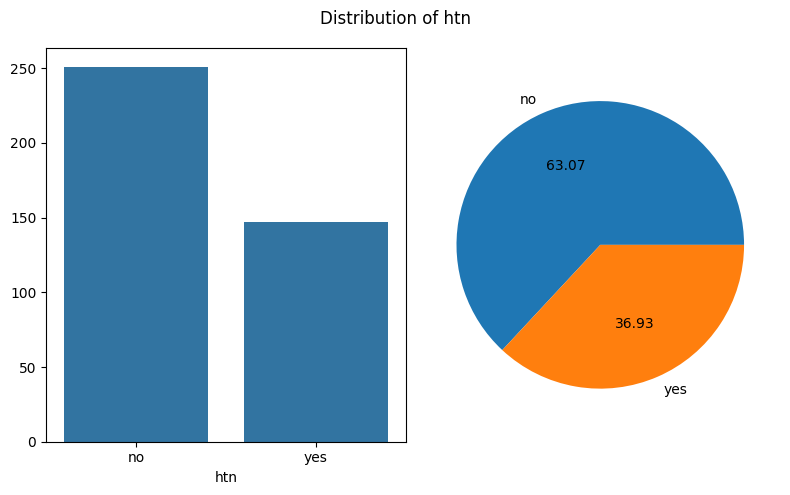

dm
no     261
yes    137
Name: count, dtype: int64


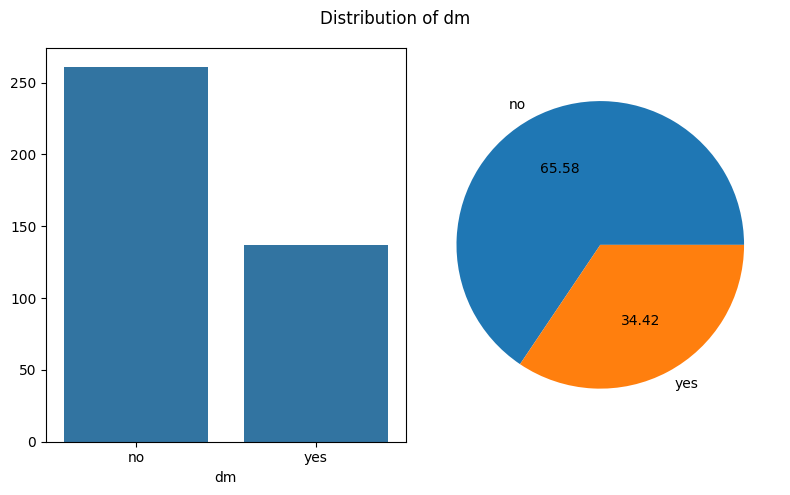

cad
no     364
yes     34
Name: count, dtype: int64


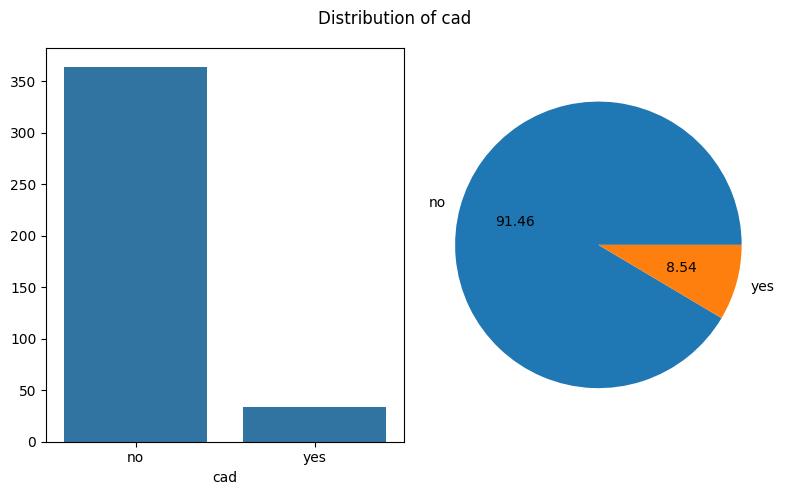

appet
good    317
poor     82
Name: count, dtype: int64


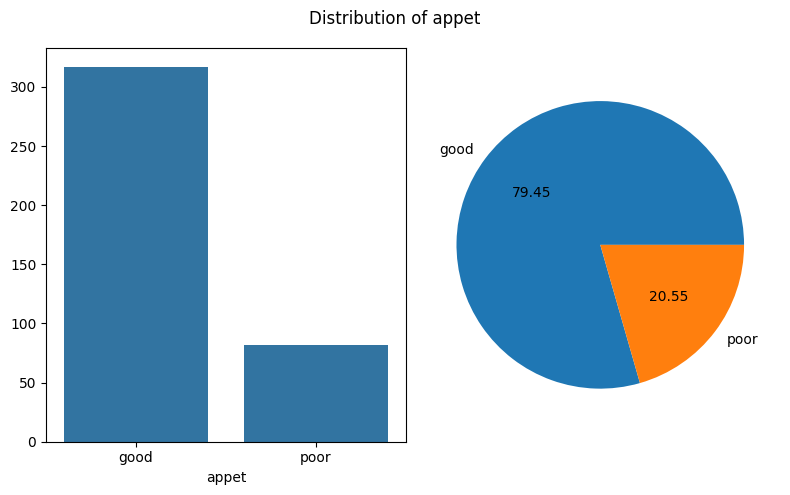

pe
no     323
yes     76
Name: count, dtype: int64


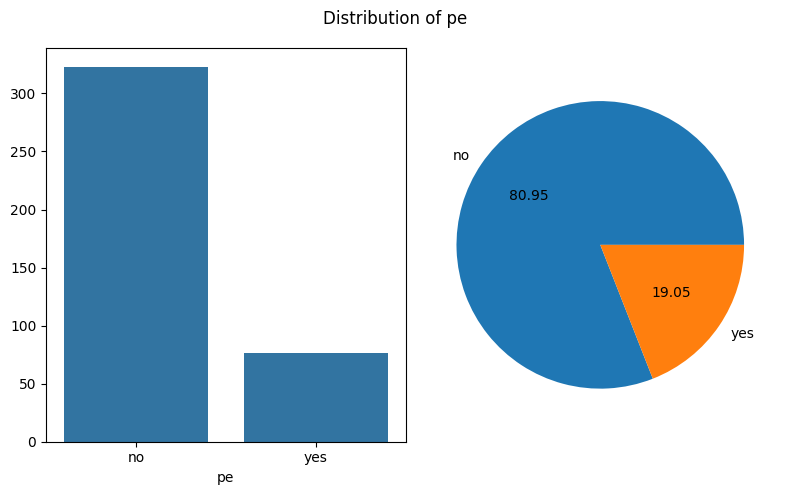

ane
no     339
yes     60
Name: count, dtype: int64


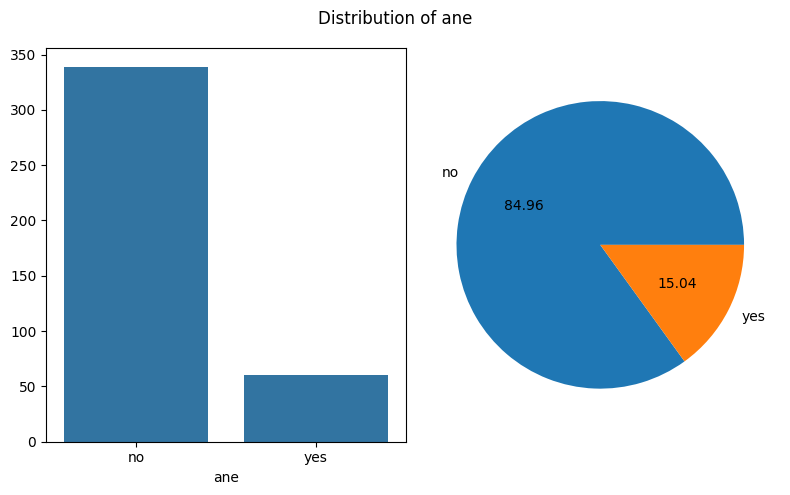

In [24]:
for categorical_col in categorical_columns:
    univariate_categorical(categorical_col)
    print("="*100)
    print("="*100)

### **Conclusions**
1. **The categories of these columns pcc, ba, cad, ane, pe are highly imbalanced, *no* being the majority in pe and ane, *not* present in case of pcc, ba and cad.** <br>
2. **The categories of these columns pc, htn, dm and appet are moderately imbalanced, where *no* being the majority category for htn and dm, *normal* for pc and *good* for appet.**

classification
ckd       250
notckd    150
Name: count, dtype: int64

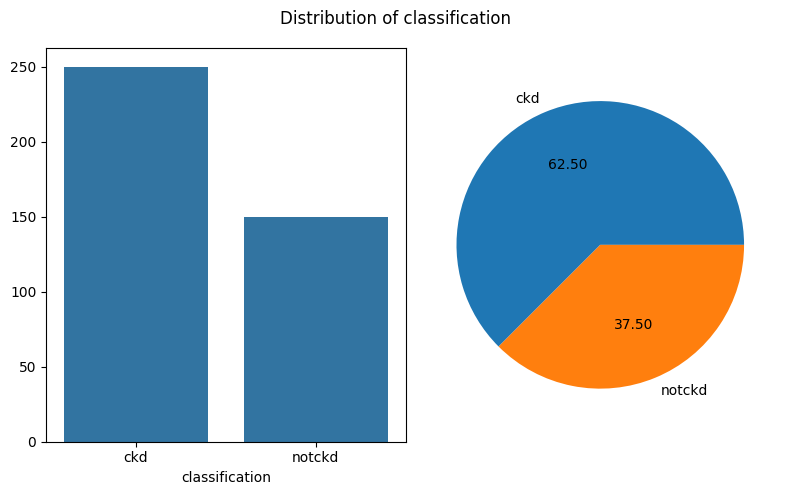

In [25]:
# univariate analysis of target column
univariate_categorical('classification')

### **Conclusion**
**The target column is moderately imbalanced with *ckd* in majority and *notckd* in minority.**

### **Bivariate Analysis**

In [26]:
def bivariate_numerical(col):
    fig, ax = plt.subplots(1, 2, figsize=(8, 5))

    # plot kdeplot
    sns.kdeplot(df_new, x=col, hue='classification', ax=ax[0])

    # plot boxplot
    sns.boxplot(df_new, x='classification', y=col, ax=ax[1])

    # set the title of the figure
    fig.suptitle(f"classification vs {col}")

    plt.tight_layout()
    plt.show()

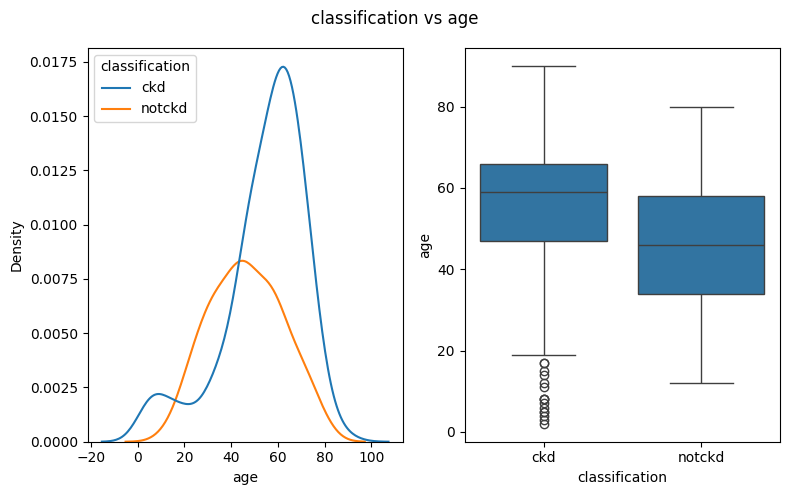

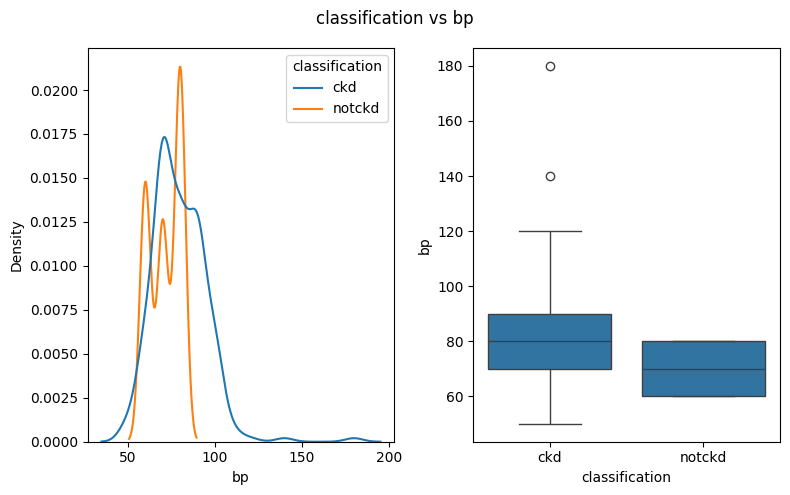

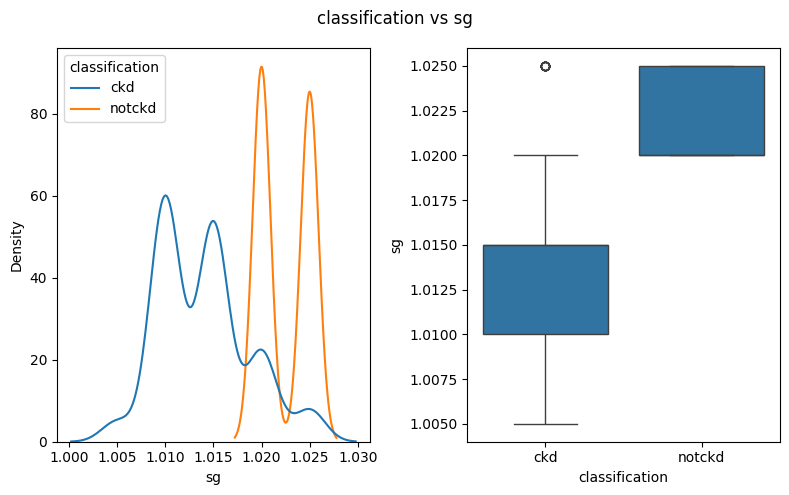

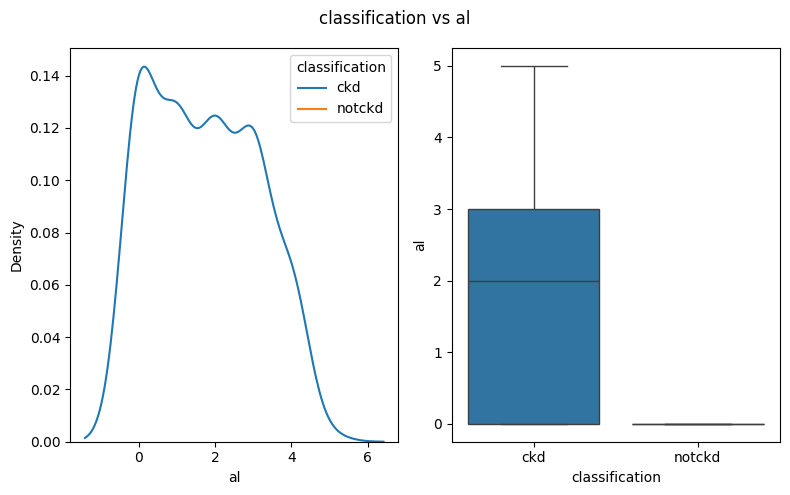

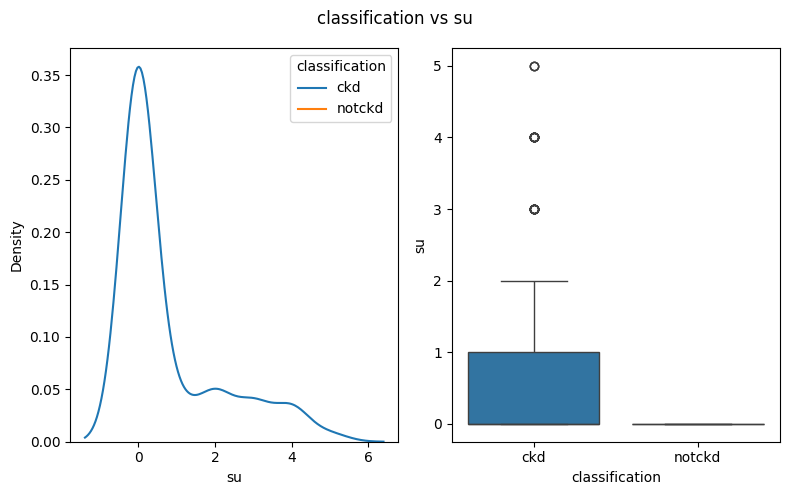

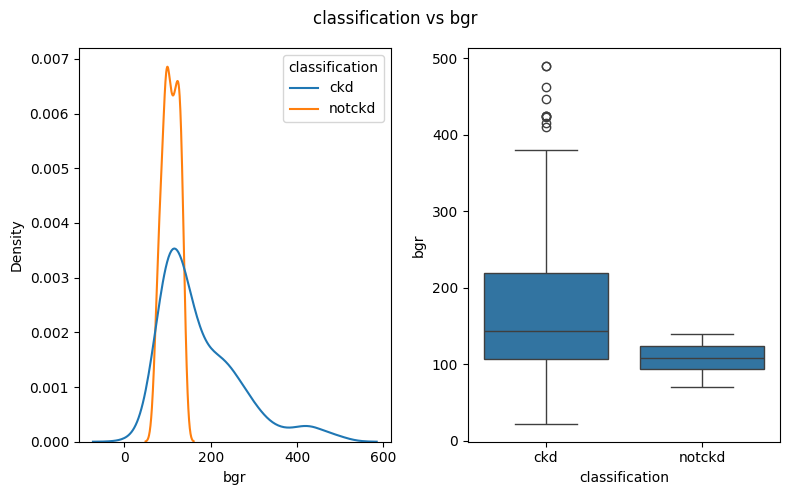

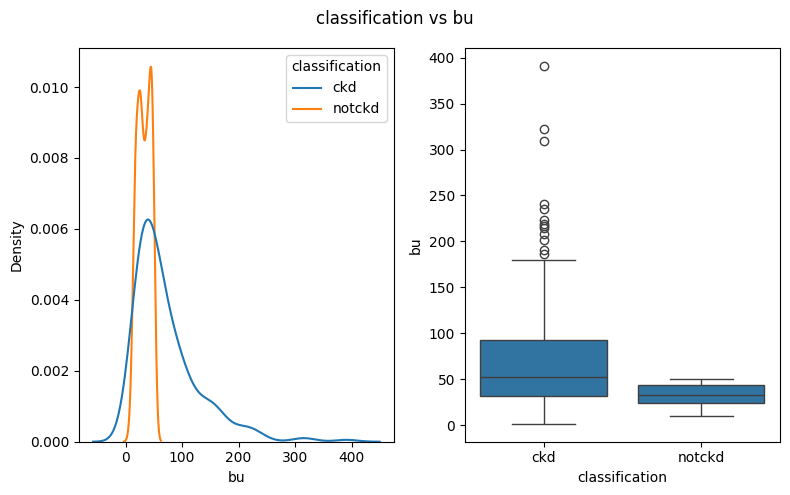

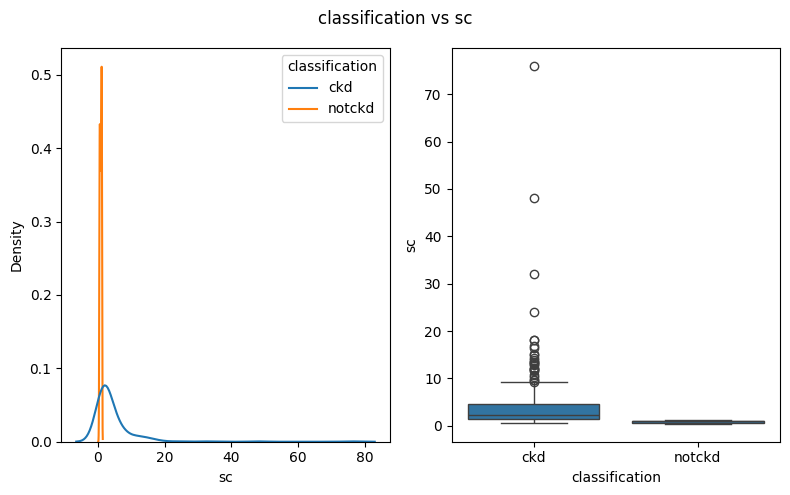

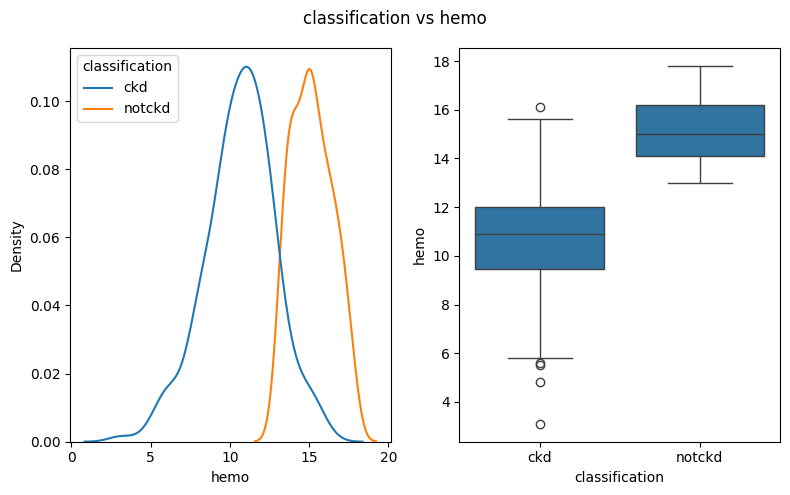

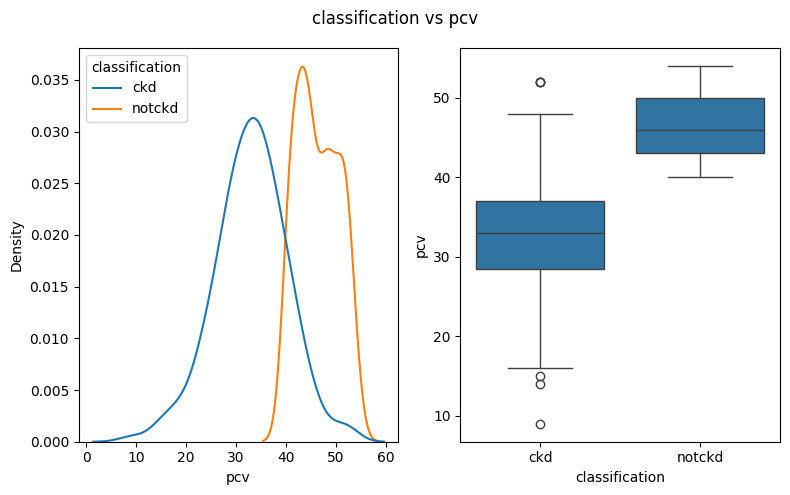

In [27]:
for numerical_col in numerical_columns:
    bivariate_numerical(numerical_col)
    print("="*100)
    print("="*100)

In [28]:
def bivariate_categorical(col):
    # display the contigency table
    print(round(pd.crosstab(df_new[col], df_new['classification'], normalize='index') * 100, 2))
    # plot the bar chart
    sns.countplot(df_new, x=col, hue='classification')
    plt.title(f"classification vs {col}")
    plt.show()

classification     ckd  notckd
pc                            
abnormal        100.00    0.00
normal           45.56   54.44


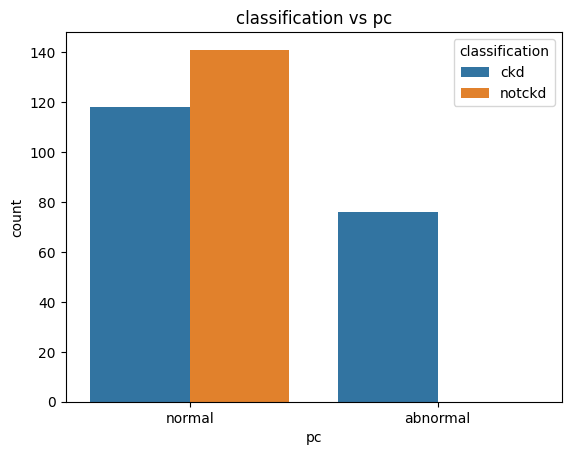

classification     ckd  notckd
pcc                           
notpresent       58.76   41.24
present         100.00    0.00


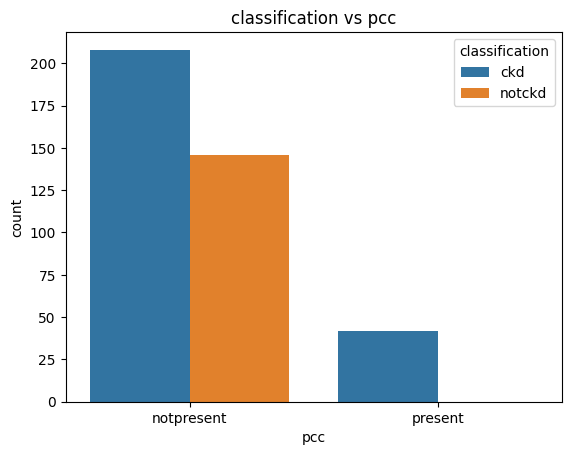

classification     ckd  notckd
ba                            
notpresent       60.96   39.04
present         100.00    0.00


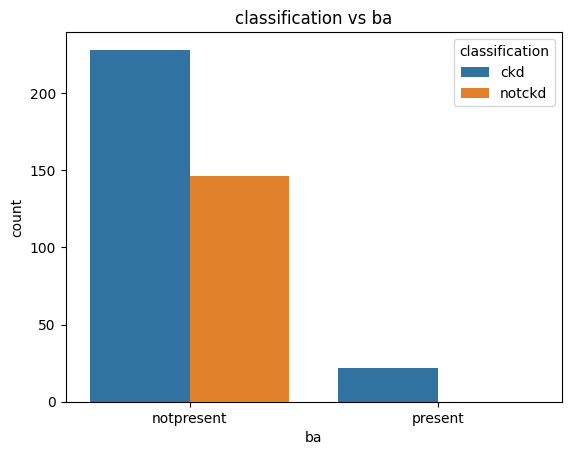

classification     ckd  notckd
htn                           
no               41.04   58.96
yes             100.00    0.00


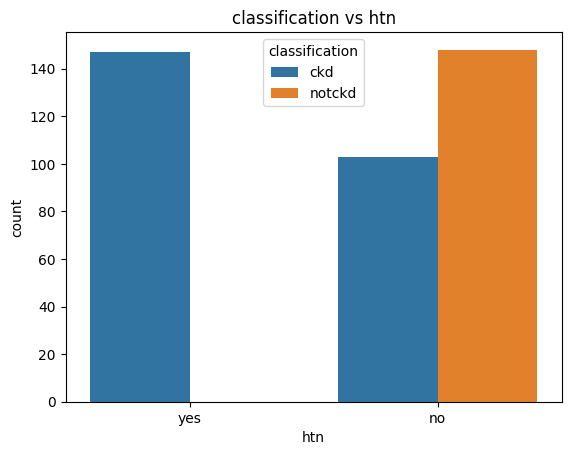

classification    ckd  notckd
dm                           
no               43.3    56.7
yes             100.0     0.0


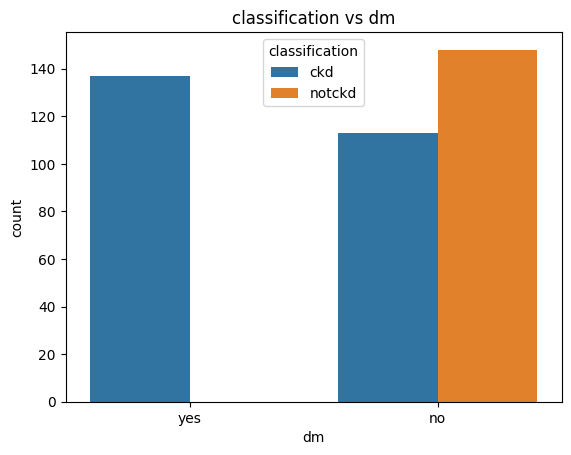

classification     ckd  notckd
cad                           
no               59.34   40.66
yes             100.00    0.00


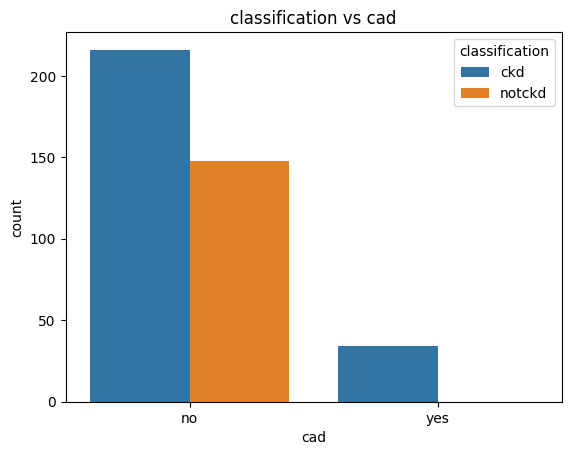

classification    ckd  notckd
appet                        
good             53.0    47.0
poor            100.0     0.0


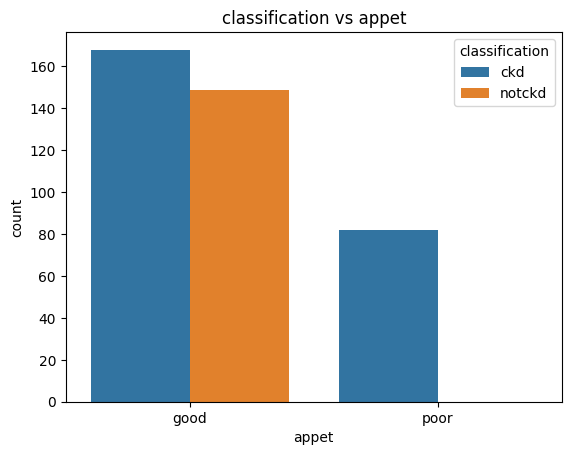

classification     ckd  notckd
pe                            
no               53.87   46.13
yes             100.00    0.00


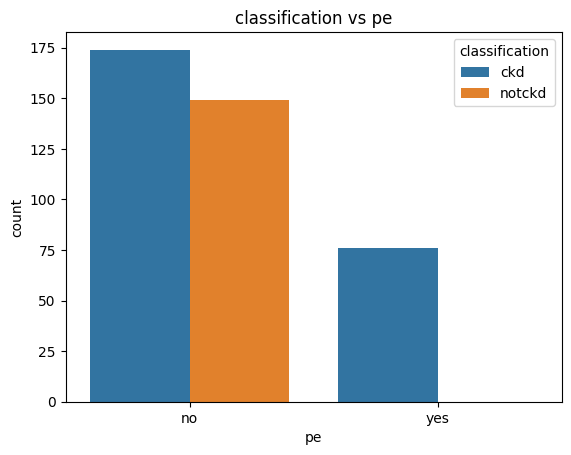

classification     ckd  notckd
ane                           
no               56.05   43.95
yes             100.00    0.00


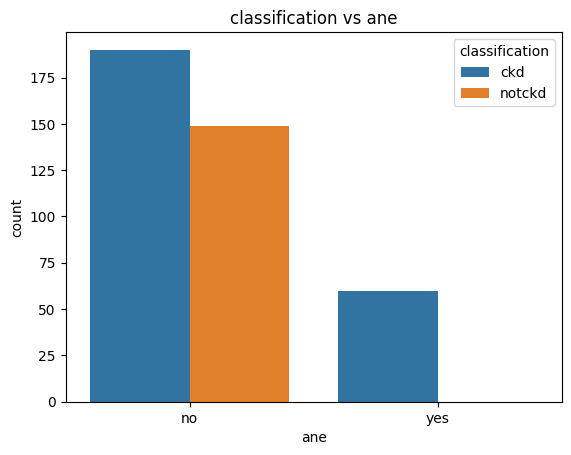

In [29]:
for categorical_col in categorical_columns:
    bivariate_categorical(categorical_col)
    print("="*100)
    print("="*100)

### **Correlation Plot**

In [30]:
# encode the target column
df_new['classification'] = df_new['classification'].replace({'ckd': 1, 'notckd': 0})
df_new.head(5)

,age,bp,sg,al,su,pc,pcc,ba,bgr,bu,sc,hemo,pcv,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,normal,notpresent,notpresent,121.0,36.0,1.2,15.4,44.0,yes,yes,no,good,no,no,1
1,7.0,50.0,1.020,4.0,0.0,normal,notpresent,notpresent,NaN,18.0,0.8,11.3,38.0,no,no,no,good,no,no,1
2,62.0,80.0,1.010,2.0,3.0,normal,notpresent,notpresent,423.0,53.0,1.8,9.6,31.0,no,yes,no,poor,no,yes,1
3,48.0,70.0,1.005,4.0,0.0,abnormal,present,notpresent,117.0,56.0,3.8,11.2,32.0,yes,no,no,poor,yes,yes,1
4,51.0,80.0,1.010,2.0,0.0,normal,notpresent,notpresent,106.0,26.0,1.4,11.6,35.0,no,no,no,good,no,no,1


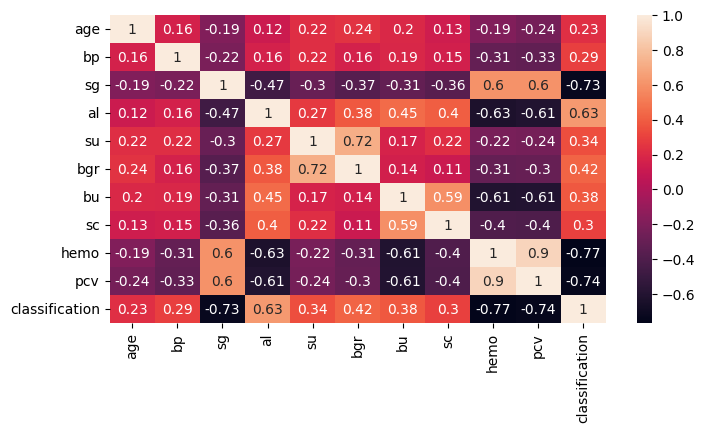

In [31]:
plt.figure(figsize=(8, 4))
sns.heatmap(df_new.corr(numeric_only=True), annot=True)
plt.show()

In [32]:
# hemo and pcv shows a high correlation among themselves, so i will remove pcv
df_new.drop(columns='pcv', inplace=True)
df_new.head(5)

,age,bp,sg,al,su,pc,pcc,ba,bgr,bu,sc,hemo,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,normal,notpresent,notpresent,121.0,36.0,1.2,15.4,yes,yes,no,good,no,no,1
1,7.0,50.0,1.020,4.0,0.0,normal,notpresent,notpresent,NaN,18.0,0.8,11.3,no,no,no,good,no,no,1
2,62.0,80.0,1.010,2.0,3.0,normal,notpresent,notpresent,423.0,53.0,1.8,9.6,no,yes,no,poor,no,yes,1
3,48.0,70.0,1.005,4.0,0.0,abnormal,present,notpresent,117.0,56.0,3.8,11.2,yes,no,no,poor,yes,yes,1
4,51.0,80.0,1.010,2.0,0.0,normal,notpresent,notpresent,106.0,26.0,1.4,11.6,no,no,no,good,no,no,1


## **Data Preprocessing**

In [33]:
# perform train test split
X_train, X_test, y_train, y_test = train_test_split(df_new.drop(columns='classification'), df_new['classification'], test_size=0.25, random_state=42)
print(f"Training Set Shape : {X_train.shape}")
print(f"Testing Set Shape : {X_test.shape}")

Training Set Shape : (300, 18)
Testing Set Shape : (100, 18)


In [39]:
# columns in which data transformation required
transformation_cols = ['bgr', 'bu', 'sc']

# define numerical cols
numerical_columns = df_new.select_dtypes('float64').columns

In [52]:
# define the categorical pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', dtype='int', handle_unknown='ignore'))
])

# define the numerical pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# define transform pipeline for columns like bgr, bu and sc which are highly skewed and have outliers
transform_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('yeojohnson', PowerTransformer(method='yeo-johnson', standardize=True))
])

# define the transformer
transformer1 = ColumnTransformer([
    ('categorical', cat_pipeline, categorical_columns),
    ('numerical', num_pipeline, numerical_columns),
    ('transform', transform_pipeline, transformation_cols)
], remainder='passthrough')

transformer1

ColumnTransformer(remainder='passthrough',
                  transformers=[('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                                dtype='int',
                                                                handle_unknown='ignore'))]),
                                 Index(['pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane'], dtype='object')),
                                ('numerical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'hemo'], dtype='object')),
                                ('transform',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('yeojohnson',
                                                  PowerTransformer())]),
                                 ['bgr', 'bu', 'sc'])])

## **ML Algorithms**

### **1. Logistic Regression**

In [53]:
log_reg_pipeline = Pipeline(
    [('preprocessor', transformer1),
     ('model', LogisticRegression())]
)

# fit the data into the algorithm
log_reg_pipeline.fit(X_train, y_train)

# get predictions on test data
y_pred1 = log_reg_pipeline.predict(X_test)

In [72]:
# define a function to evaluate the model
def model_evaluation(y_test: np.ndarray, y_pred: np.ndarray) -> None:
    print(f"Accuracy : {round(accuracy_score(y_test, y_pred) * 100, 2)}%")
    print('='*100)

    print(classification_report(y_test, y_pred))
    print('='*100)

    print(f"AUC Score : {round(roc_auc_score(y_test, y_pred), 2)}")
    print('='*100)

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title("Confusion Matrix")
    plt.show()

Accuracy : 100.0%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       1.00      1.00      1.00        65

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

AUC Score : 1.0


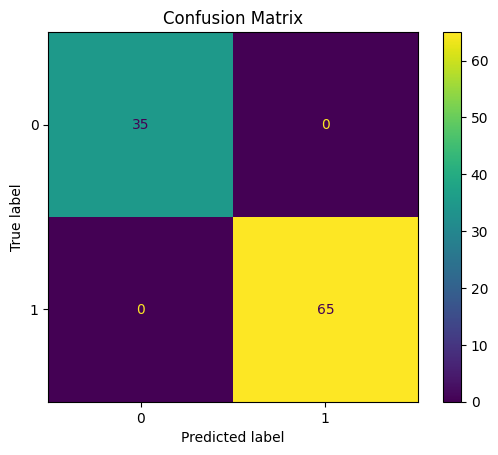

In [80]:
model_evaluation(y_test, y_pred1)

In [83]:
# cross validating the results
print(cross_val_score(log_reg_pipeline, X_train, y_train, cv=5, scoring='accuracy'))
print(f"Mean Accuracy : {round(cross_val_score(log_reg_pipeline, X_train, y_train, cv=5, scoring='accuracy').mean() * 100, 2)}%")

[0.98333333 0.96666667 1.         1.         1.        ]
Mean Accuracy : 99.0%


### **2. SVC**

In [89]:
svc_pipeline = Pipeline(
    [('preprocessor', transformer1),
     ('model', SVC())]
)

# fit the data into the algorithm
svc_pipeline.fit(X_train, y_train)

# get predictions on test data
y_pred2 = svc_pipeline.predict(X_test)

Accuracy : 98.0%
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        35
           1       1.00      0.97      0.98        65

    accuracy                           0.98       100
   macro avg       0.97      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100

AUC Score : 0.98


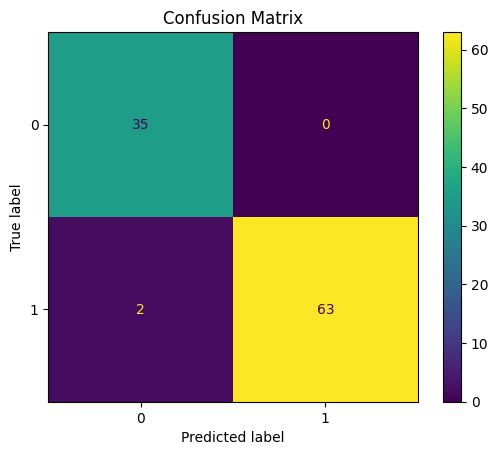

In [90]:
model_evaluation(y_test, y_pred2)

In [91]:
# cross validating the results
svc_cv_scores = cross_val_score(svc_pipeline, X_train, y_train, cv=5, scoring='accuracy')
print(svc_cv_scores)
print(f"Mean Accuracy : {round(svc_cv_scores.mean() * 100, 2)}%")

[0.98333333 0.96666667 1.         1.         1.        ]
Mean Accuracy : 99.0%


### **3. Random Forest**

In [92]:
# define the random forest pipeline
rf_pipeline = Pipeline(
    [('preprocessor', transformer1),
     ('model', RandomForestClassifier())]
)

# fit the data into the algorithm
rf_pipeline.fit(X_train, y_train)

# get predictions on test data
y_pred3 = rf_pipeline.predict(X_test)

Accuracy : 100.0%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       1.00      1.00      1.00        65

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

AUC Score : 1.0


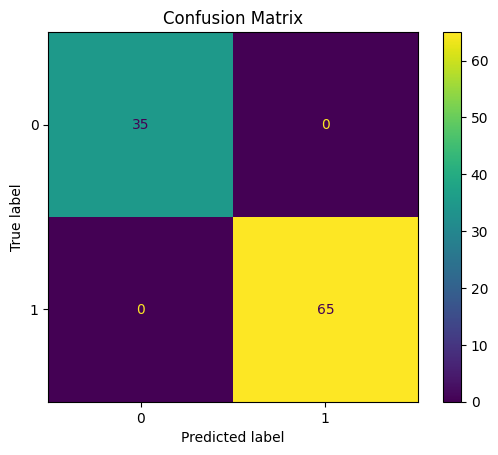

In [93]:
model_evaluation(y_test, y_pred3)

In [94]:
# cross validating the results
rf_cv_scores = cross_val_score(rf_pipeline, X_train, y_train, cv=5, scoring='accuracy')
print(rf_cv_scores)
print(f"Mean Accuracy : {round(rf_cv_scores.mean() * 100, 2)}%")

[0.98333333 1.         1.         1.         0.98333333]
Mean Accuracy : 99.33%


### **4. KNN**

In [95]:
# define the knn pipeline
knn_pipeline = Pipeline(
    [('preprocessor', transformer1),
     ('model', KNeighborsClassifier())]
)

# fit the data into the algorithm
knn_pipeline.fit(X_train, y_train)

# get predictions on test data
y_pred4 = knn_pipeline.predict(X_test)

Accuracy : 95.0%
              precision    recall  f1-score   support

           0       0.88      1.00      0.93        35
           1       1.00      0.92      0.96        65

    accuracy                           0.95       100
   macro avg       0.94      0.96      0.95       100
weighted avg       0.96      0.95      0.95       100

AUC Score : 0.96


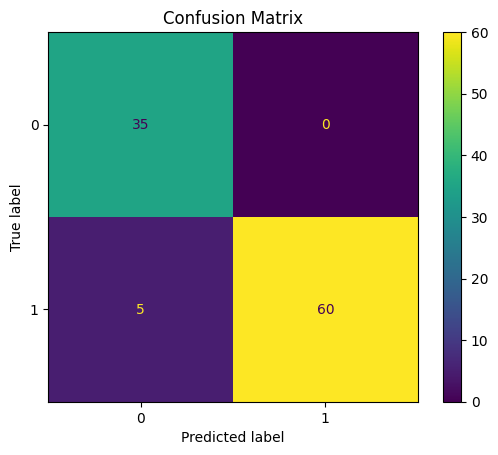

In [96]:
model_evaluation(y_test, y_pred4)

In [97]:
# cross validating the results
knn_cv_scores = cross_val_score(knn_pipeline, X_train, y_train, cv=5, scoring='accuracy')
print(knn_cv_scores)
print(f"Mean Accuracy : {round(knn_cv_scores.mean() * 100, 2)}%")

[0.93333333 0.93333333 0.96666667 1.         0.96666667]
Mean Accuracy : 96.0%


### **5. Gradient Boosting Classifier**

In [98]:
# define the gradient boosting pipeline
gb_pipeline = Pipeline(
    [('preprocessor', transformer1),
     ('model', GradientBoostingClassifier())]
)

# fit the data into the algorithm
gb_pipeline.fit(X_train, y_train)

# get predictions on test data
y_pred5 = gb_pipeline.predict(X_test)

Accuracy : 100.0%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       1.00      1.00      1.00        65

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

AUC Score : 1.0


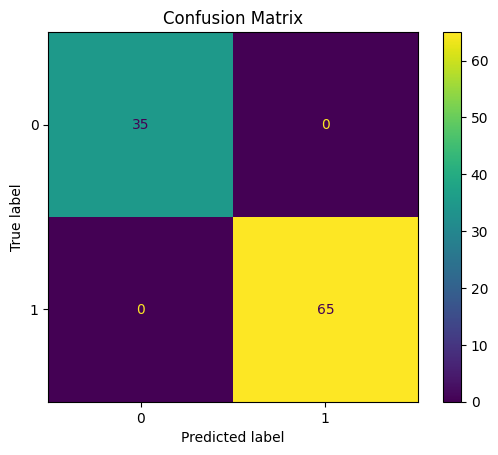

In [99]:
model_evaluation(y_test, y_pred5)

In [100]:
# cross validating the results
gb_cv_scores = cross_val_score(gb_pipeline, X_train, y_train, cv=5, scoring='accuracy')
print(gb_cv_scores)
print(f"Mean Accuracy : {round(gb_cv_scores.mean() * 100, 2)}%")

[0.98333333 1.         0.96666667 0.98333333 0.93333333]
Mean Accuracy : 97.33%


## **Hyperparameter Tuning**

As we can see multiple models like **Logistic Regression**, **SVC** and **Random Forest** worked well on the data so I am performing Hyperparameter Tuning in **Random Forest** for better generalization.

In [103]:
# define the parameters for grid search
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5],
    'model__max_features': ['sqrt', 'log2']
}

rf_grid_search = GridSearchCV(estimator=rf_pipeline,
                              param_grid=param_grid,
                              cv=5,
                              scoring=['accuracy', 'roc_auc', 'recall'],
                              n_jobs=-1,
                              refit='roc_auc')

In [104]:
# fit the grid search to the data
rf_grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        dtype='int',
                                                                                                        handle_unknown='ignore'))]),
                                                                         Index(['pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane'], dtype='object'...
                                                                         Index(['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'hemo'], dtype='object')),
                                                                        ('transform',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('yeojohnson',
                                                                                          PowerTransformer())]),
                                                                         ['bgr',
                                                                          'bu',
                                                                          'sc'])])),
                                       ('model', RandomForestClassifier())]),
             n_jobs=-1,
             param_grid={'model__max_depth': [3, 5],
                         'model__max_features': ['sqrt', 'log2'],
                         'model__n_estimators': [100, 200]},
             refit='roc_auc', scoring=['accuracy', 'roc_auc', 'recall'])

In [107]:
print(f" Best Parameters:\n{rf_grid_search.best_params_}")
print(f"Best Score : {round(rf_grid_search.best_score_, 2)}")

 Best Parameters:
{'model__max_depth': 3, 'model__max_features': 'sqrt', 'model__n_estimators': 100}
Best Score : 1.0


Accuracy : 100.0%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       1.00      1.00      1.00        65

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

AUC Score : 1.0


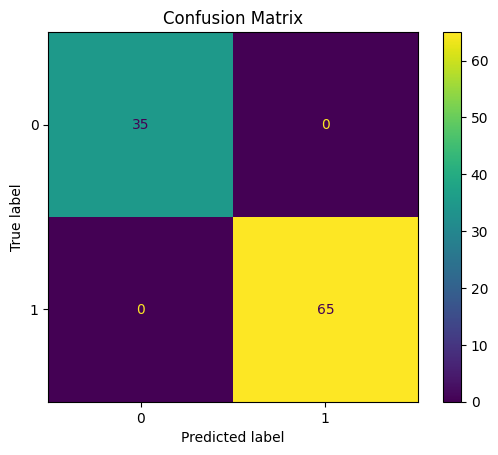

In [110]:
y_pred6 = rf_grid_search.predict(X_test)

model_evaluation(y_test, y_pred6)

## **Export the Model**

In [112]:
# export the model
import pickle

with open('../model/rf_grid_search.pkl', 'wb') as file:
    pickle.dump(rf_grid_search, file)